# VAE + TFT Transfer Learning for Battery RUL

This notebook runs transfer learning in both directions:

1. HNEI -> NASA
2. NASA -> HNEI

For each direction, the workflow is:

1. Train a VAE on the source-domain feature windows.
2. Freeze the VAE encoder and use it to create latent degradation features for source and target batteries.
3. Train a TFT RUL model on the source domain with raw features plus frozen VAE latent features.
4. Evaluate zero-shot transfer on the target test batteries.
5. Fine-tune the TFT on a small target-domain training subset and evaluate on held-out target batteries.

The VAE encoder is not updated during target fine-tuning. Only the TFT is fine-tuned on the target domain.


In [1]:
# If the imports below fail, uncomment and run this cell once.
# %pip install -q lightning pytorch-forecasting


In [2]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import RMSE
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger

import matplotlib.pyplot as plt

SEED = 42
seed_everything(SEED, workers=True)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")


Seed set to 42


Using device: mps


In [3]:
DATA_PATH = Path("combined_scaled_battery_data.csv")
MODEL_TARGET_COL = "target_scaled"
MODEL_TIME_COL = "cycle_scaled"

RENAMES = {
    "Cycle_Index": "time_idx",
    "Discharge Time (s)": "discharge_time",
    "Decrement 3.6-3.4V (s)": "decrement_36_34",
    "Max. Voltage Dischar. (V)": "max_voltage_discharge",
    "Min. Voltage Charg. (V)": "min_voltage_charge",
    "Time at 4.15V (s)": "time_at_415",
    "Time constant current (s)": "time_constant_current",
    "Charging time (s)": "charging_time",
    "RUL": "target",
}

RAW_FEATURE_COLS = [
    "discharge_time",
    "decrement_36_34",
    "max_voltage_discharge",
    "min_voltage_charge",
    "time_at_415",
    "time_constant_current",
    "charging_time",
]

# Keep VAE_WINDOW_LENGTH aligned with TFT history length so each latent describes
# the same recent degradation context the TFT sees.
VAE_WINDOW_LENGTH = 20
MAX_ENCODER_LENGTH = 20
MAX_PREDICTION_LENGTH = 1

LATENT_DIM = 8
VAE_HIDDEN_SIZE = 64
VAE_BATCH_SIZE = 256
VAE_EPOCHS = 20
VAE_LR = 1e-3
VAE_BETA = 1e-3

TFT_BATCH_SIZE = 64
TFT_SOURCE_EPOCHS = 15
TFT_TRANSFER_EPOCHS = 10
# Target-only starts from random weights, so give it a larger early-stopped budget while keeping the same target batteries.
TFT_TARGET_ONLY_EPOCHS = 20
TFT_SOURCE_LR = 3e-2
TFT_TRANSFER_LR = 5e-3

# Fraction of target-domain training batteries used for fine-tuning.
# Increase to 1.0 if you want full-target fine-tuning instead of the small-data setup.
TARGET_TRAIN_FRACTION = 0.35

# False matches the VAE-transfer idea: raw features -> frozen VAE encoder -> latent -> TFT head -> normalized RUL.
# Set True for a hybrid TFT that sees both raw cycle features and frozen VAE latents.
USE_RAW_FEATURES_IN_TFT = False

# RUL cannot be negative; clipping is applied only after converting predictions back to cycles.
CLIP_NEGATIVE_RUL_PREDICTIONS = True


## Load and Split Batteries

`Is_NASA == 0` is treated as HNEI and `Is_NASA == 1` is treated as NASA. Splits are done at the battery level so the model is tested on unseen batteries, not later cycles from batteries it already saw.


In [4]:
def load_battery_dataframe(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path).rename(columns=RENAMES).reset_index(drop=True)
    df["domain"] = np.where(df["Is_NASA"].astype(int) == 1, "nasa", "hnei")

    # Each source file is ordered by battery, and a new battery starts when the
    # cycle index resets to 1. Prefixing by domain keeps IDs readable and unique.
    segment_id = (df["time_idx"] == 1).cumsum() - 1
    df["battery_id"] = df["domain"] + "_" + segment_id.astype(str)

    df = df.sort_values(["battery_id", "time_idx"]).reset_index(drop=True)
    df["battery_id"] = df["battery_id"].astype(str)
    df["time_idx"] = df["time_idx"].astype(int)
    df["target"] = df["target"].astype(float)
    for col in RAW_FEATURE_COLS:
        df[col] = df[col].astype(float)
    return df


def summarize_domains(df: pd.DataFrame) -> pd.DataFrame:
    per_battery = df.groupby(["domain", "battery_id"]).agg(
        rows=("time_idx", "size"),
        min_cycle=("time_idx", "min"),
        max_cycle=("time_idx", "max"),
        min_rul=("target", "min"),
        median_rul=("target", "median"),
        max_rul=("target", "max"),
    )
    return per_battery.groupby("domain").agg(
        batteries=("rows", "count"),
        rows=("rows", "sum"),
        min_len=("rows", "min"),
        median_len=("rows", "median"),
        max_len=("rows", "max"),
        min_rul=("min_rul", "min"),
        median_rul=("median_rul", "median"),
        max_rul=("max_rul", "max"),
    )


df = load_battery_dataframe(DATA_PATH)
print(df.shape)
display(df.head())
display(summarize_domains(df))


(17658, 12)


,time_idx,discharge_time,decrement_36_34,max_voltage_discharge,min_voltage_charge,time_at_415,time_constant_current,charging_time,target,Is_NASA,domain,battery_id
0,1,0.909368,2.248505,-2.808054,-3.115605,2.005705,1.867079,2.297202,1112.0,0,hnei,hnei_0
1,2,5.241828,2.317965,4.102902,-3.039831,2.045062,1.871526,2.039997,1111.0,0,hnei,hnei_0
2,3,5.228434,2.121319,4.138897,-3.006154,2.045063,1.871526,1.965868,1110.0,0,hnei,hnei_0
3,4,5.220999,2.013378,4.150895,-2.997735,2.039458,1.871526,1.875424,1109.0,0,hnei,hnei_0
4,6,57.099956,96.943238,4.630822,-1.541204,2.022568,31.339883,44.865103,1107.0,0,hnei,hnei_0


,batteries,rows,min_len,median_len,max_len,min_rul,median_rul,max_rul
domain,,,,,,,,
hnei,14,14874,1039,1065.0,1067,1.0,546.25,1133.0
nasa,34,2784,24,68.5,197,0.0,34.25,196.0


In [5]:
def split_domain_by_battery(
    df: pd.DataFrame,
    domain: str,
    test_size: float = 0.20,
    val_size_of_remaining: float = 0.20,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    domain_df = df[df["domain"] == domain].copy()
    battery_ids = np.array(sorted(domain_df["battery_id"].unique()))

    train_val_ids, test_ids = train_test_split(
        battery_ids, test_size=test_size, random_state=seed, shuffle=True
    )
    train_ids, val_ids = train_test_split(
        train_val_ids, test_size=val_size_of_remaining, random_state=seed, shuffle=True
    )

    train_df = domain_df[domain_df["battery_id"].isin(train_ids)].copy()
    val_df = domain_df[domain_df["battery_id"].isin(val_ids)].copy()
    test_df = domain_df[domain_df["battery_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df


def keep_fraction_of_batteries(
    domain_train_df: pd.DataFrame,
    fraction: float,
    seed: int = SEED,
) -> pd.DataFrame:
    if fraction >= 1.0:
        return domain_train_df.copy()
    battery_ids = np.array(sorted(domain_train_df["battery_id"].unique()))
    n_keep = max(1, math.ceil(len(battery_ids) * fraction))
    rng = np.random.default_rng(seed)
    keep_ids = rng.choice(battery_ids, size=n_keep, replace=False)
    return domain_train_df[domain_train_df["battery_id"].isin(keep_ids)].copy()


def build_domain_scalers(df: pd.DataFrame) -> dict[str, dict[str, float]]:
    """Build one min-max scaler per dataset/domain.

    This intentionally normalizes HNEI and NASA separately so each dataset's RUL
    values are in [0, 1]. Predictions are inverted with the same scaler before
    computing cycle-unit metrics.
    """
    scalers = {}
    for domain, domain_df in df.groupby("domain"):
        target_min = float(domain_df["target"].min())
        target_max = float(domain_df["target"].max())
        time_min = float(domain_df["time_idx"].min())
        time_max = float(domain_df["time_idx"].max())
        if target_max <= target_min:
            raise ValueError(f"Invalid target range for {domain}: {target_min}, {target_max}")
        if time_max <= time_min:
            raise ValueError(f"Invalid time range for {domain}: {time_min}, {time_max}")
        scalers[domain] = {
            "target_min": target_min,
            "target_max": target_max,
            "target_range": target_max - target_min,
            "time_min": time_min,
            "time_max": time_max,
            "time_range": time_max - time_min,
        }
    return scalers


def add_normalized_columns(data: pd.DataFrame, scaler: dict[str, float]) -> pd.DataFrame:
    result = data.copy()
    result[MODEL_TARGET_COL] = (result["target"] - scaler["target_min"]) / scaler["target_range"]
    result[MODEL_TIME_COL] = (result["time_idx"] - scaler["time_min"]) / scaler["time_range"]
    return result


def inverse_target_scale(values_scaled: np.ndarray, scaler: dict[str, float]) -> np.ndarray:
    return values_scaled * scaler["target_range"] + scaler["target_min"]


splits = {
    domain: split_domain_by_battery(df, domain)
    for domain in ["hnei", "nasa"]
}
domain_scalers = build_domain_scalers(df)

for domain, (train_df, val_df, test_df) in splits.items():
    scaler = domain_scalers[domain]
    full_domain = add_normalized_columns(df[df["domain"] == domain], scaler)
    print(f"{domain.upper()} split")
    print(f"  train: {train_df.shape}, batteries={train_df['battery_id'].nunique()}")
    print(f"  val:   {val_df.shape}, batteries={val_df['battery_id'].nunique()}")
    print(f"  test:  {test_df.shape}, batteries={test_df['battery_id'].nunique()}")
    print(
        f"  target scaler: min={scaler['target_min']:.2f}, max={scaler['target_max']:.2f}; "
        f"normalized range=[{full_domain[MODEL_TARGET_COL].min():.3f}, {full_domain[MODEL_TARGET_COL].max():.3f}]"
    )


HNEI split
  train: (8486, 12), batteries=8
  val:   (3197, 12), batteries=3
  test:  (3191, 12), batteries=3
  target scaler: min=1.00, max=1133.00; normalized range=[0.000, 1.000]
NASA split
  train: (1508, 12), batteries=21
  val:   (846, 12), batteries=6
  test:  (430, 12), batteries=7
  target scaler: min=0.00, max=196.00; normalized range=[0.000, 1.000]


## VAE Encoder

The VAE sees only raw cycle-level features. After source-domain VAE training, the encoder is frozen and used as a latent feature generator for both source and target domains.


In [6]:
class FeatureWindowDataset(Dataset):
    def __init__(self, data: pd.DataFrame, feature_cols: list[str], window_length: int):
        windows = []
        for _, group in data.groupby("battery_id", sort=False):
            values = group[feature_cols].to_numpy(dtype=np.float32)
            if len(values) < 2:
                continue
            for end in range(len(values)):
                start = max(0, end - window_length + 1)
                window = values[start : end + 1]
                if len(window) < window_length:
                    pad = np.repeat(window[:1], window_length - len(window), axis=0)
                    window = np.vstack([pad, window])
                windows.append(window)
        self.windows = torch.tensor(np.stack(windows), dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.windows[idx]


class SequenceVAE(nn.Module):
    def __init__(self, num_features: int, hidden_size: int, latent_dim: int):
        super().__init__()
        self.encoder = nn.GRU(num_features, hidden_size, batch_first=True)
        self.mu = nn.Linear(hidden_size, latent_dim)
        self.logvar = nn.Linear(hidden_size, latent_dim)

        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size)
        self.decoder = nn.GRU(num_features, hidden_size, batch_first=True)
        self.reconstruction = nn.Linear(hidden_size, num_features)

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        _, h = self.encoder(x)
        h = h[-1]
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor, seq_len: int, num_features: int) -> torch.Tensor:
        h0 = self.latent_to_hidden(z).unsqueeze(0)
        decoder_input = torch.zeros(z.size(0), seq_len, num_features, device=z.device)
        decoded, _ = self.decoder(decoder_input, h0)
        return self.reconstruction(decoded)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, x.size(1), x.size(2))
        return recon, mu, logvar


def vae_loss(
    recon: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = VAE_BETA,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    reconstruction_loss = nn.functional.mse_loss(recon, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = reconstruction_loss + beta * kl_loss
    return total, reconstruction_loss, kl_loss


def train_vae(source_train_df: pd.DataFrame, direction_name: str) -> SequenceVAE:
    dataset = FeatureWindowDataset(source_train_df, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH)
    loader = DataLoader(dataset, batch_size=VAE_BATCH_SIZE, shuffle=True, num_workers=0)

    model = SequenceVAE(
        num_features=len(RAW_FEATURE_COLS),
        hidden_size=VAE_HIDDEN_SIZE,
        latent_dim=LATENT_DIM,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=VAE_LR)

    history = []
    for epoch in range(1, VAE_EPOCHS + 1):
        model.train()
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0
        n_seen = 0
        for batch in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            total, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar)
            total.backward()
            optimizer.step()

            batch_size = batch.size(0)
            running_total += total.item() * batch_size
            running_recon += recon_loss.item() * batch_size
            running_kl += kl_loss.item() * batch_size
            n_seen += batch_size

        row = {
            "epoch": epoch,
            "loss": running_total / n_seen,
            "reconstruction_loss": running_recon / n_seen,
            "kl_loss": running_kl / n_seen,
        }
        history.append(row)
        if epoch == 1 or epoch % 5 == 0 or epoch == VAE_EPOCHS:
            print(
                f"[{direction_name} VAE] epoch {epoch:02d}/{VAE_EPOCHS} "
                f"loss={row['loss']:.5f} recon={row['reconstruction_loss']:.5f} kl={row['kl_loss']:.5f}"
            )

    model.history_ = pd.DataFrame(history)
    return model


In [7]:
@torch.no_grad()
def add_frozen_vae_latents(
    data: pd.DataFrame,
    vae: SequenceVAE,
    feature_cols: list[str],
    window_length: int,
    latent_dim: int,
    batch_size: int = 1024,
) -> tuple[pd.DataFrame, list[str]]:
    vae.eval()
    windows = []
    row_indices = []

    for _, group in data.groupby("battery_id", sort=False):
        values = group[feature_cols].to_numpy(dtype=np.float32)
        indices = group.index.to_numpy()
        for pos, idx in enumerate(indices):
            start = max(0, pos - window_length + 1)
            window = values[start : pos + 1]
            if len(window) < window_length:
                pad = np.repeat(window[:1], window_length - len(window), axis=0)
                window = np.vstack([pad, window])
            windows.append(window)
            row_indices.append(idx)

    latent_chunks = []
    for start in range(0, len(windows), batch_size):
        batch = torch.tensor(np.stack(windows[start : start + batch_size]), dtype=torch.float32, device=DEVICE)
        mu, _ = vae.encode(batch)
        latent_chunks.append(mu.cpu().numpy())

    latents = np.vstack(latent_chunks)
    latent_cols = [f"vae_latent_{i:02d}" for i in range(latent_dim)]

    result = data.copy()
    for col in latent_cols:
        result[col] = np.nan
    result.loc[row_indices, latent_cols] = latents
    result[latent_cols] = result[latent_cols].astype(float)
    return result, latent_cols


## TFT Helpers

The TFT now predicts normalized RUL (`target_scaled`) instead of raw cycle counts. HNEI and NASA each get their own min-max target scaler, so each dataset is mapped to `[0, 1]`. Metrics and plots are converted back to original cycle units with the matching dataset scaler.

The model-visible cycle index is also normalized as `cycle_scaled`; raw `time_idx` is still used internally only for ordering the time series.


In [8]:
def make_source_tft_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    latent_cols: list[str],
) -> tuple[TimeSeriesDataSet, TimeSeriesDataSet, TimeSeriesDataSet]:
    tft_reals = (RAW_FEATURE_COLS if USE_RAW_FEATURES_IN_TFT else []) + latent_cols
    print(f"TFT input reals: {tft_reals}")
    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=MODEL_TARGET_COL,
        group_ids=["battery_id"],
        categorical_encoders={
            "battery_id": NaNLabelEncoder(add_nan=True),
            "__group_id__battery_id": NaNLabelEncoder(add_nan=True),
        },
        min_encoder_length=1,
        max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=1,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=[],
        static_reals=[],
        time_varying_known_reals=[MODEL_TIME_COL],
        time_varying_unknown_reals=tft_reals,
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        target_normalizer=None,
        allow_missing_timesteps=True,
    )
    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=False, stop_randomization=True)
    test = TimeSeriesDataSet.from_dataset(training, test_df, predict=False, stop_randomization=True)
    return training, validation, test


def make_transfer_dataset(
    source_training: TimeSeriesDataSet,
    target_df: pd.DataFrame,
) -> TimeSeriesDataSet:
    return TimeSeriesDataSet.from_dataset(
        source_training,
        target_df,
        predict=False,
        stop_randomization=True,
    )


def make_dataloader(dataset: TimeSeriesDataSet, train: bool) -> DataLoader:
    return dataset.to_dataloader(train=train, batch_size=TFT_BATCH_SIZE, num_workers=0)


def build_tft(training: TimeSeriesDataSet, learning_rate: float) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=16,
        attention_head_size=2,
        dropout=0.1,
        hidden_continuous_size=8,
        output_size=1,
        loss=RMSE(),
        reduce_on_plateau_patience=3,
    )


def fit_tft(
    model: TemporalFusionTransformer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int,
    experiment_name: str,
) -> TemporalFusionTransformer:
    early_stop = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-4,
        patience=5,
        mode="min",
    )
    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[early_stop],
        logger=CSVLogger("lightning_logs", name=experiment_name),
        enable_checkpointing=False,
        log_every_n_steps=10,
    )
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
    return model


def evaluate_tft(
    model: TemporalFusionTransformer,
    loader: DataLoader,
    label: str,
    scaler: dict[str, float],
) -> dict[str, float | str | np.ndarray]:
    predictions_scaled = model.predict(loader)
    actuals_scaled = torch.cat([y[0] for _, y in iter(loader)])

    preds_scaled = predictions_scaled.squeeze().detach().cpu().numpy()
    acts_scaled = actuals_scaled.squeeze().detach().cpu().numpy()

    preds = inverse_target_scale(preds_scaled, scaler)
    acts = inverse_target_scale(acts_scaled, scaler)
    if CLIP_NEGATIVE_RUL_PREDICTIONS:
        preds = np.maximum(preds, 0.0)

    metrics = {
        "label": label,
        "target_min": scaler["target_min"],
        "target_max": scaler["target_max"],
        "mae": mean_absolute_error(acts, preds),
        "rmse": np.sqrt(mean_squared_error(acts, preds)),
        "r2": r2_score(acts, preds),
        "mae_scaled": mean_absolute_error(acts_scaled, preds_scaled),
        "rmse_scaled": np.sqrt(mean_squared_error(acts_scaled, preds_scaled)),
        "r2_scaled": r2_score(acts_scaled, preds_scaled),
        "preds": preds,
        "actuals": acts,
        "preds_scaled": preds_scaled,
        "actuals_scaled": acts_scaled,
    }
    print(
        f"{label}: MAE={metrics['mae']:.4f} cycles, "
        f"RMSE={metrics['rmse']:.4f} cycles, R2={metrics['r2']:.4f}; "
        f"scaled_RMSE={metrics['rmse_scaled']:.4f}, "
        f"target_range=[{scaler['target_min']:.1f}, {scaler['target_max']:.1f}]"
    )
    return metrics


## Run One Transfer Direction

This function performs the full source-to-target transfer experiment and a matched no-transfer baseline.

For each direction it reports:

1. Source-domain test performance.
2. Zero-shot target performance from the source-trained TFT.
3. Transfer + fine-tuning on the small target subset.
4. Target-only small-data baseline trained from scratch on the same target subset.


In [9]:
def run_transfer_direction(source_domain: str, target_domain: str) -> dict[str, object]:
    direction_name = f"{source_domain}_to_{target_domain}"
    target_only_name = f"{target_domain}_only_small_data"
    print("=" * 80)
    print(f"Running {source_domain.upper()} -> {target_domain.upper()}")

    source_train, source_val, source_test = splits[source_domain]
    target_train_full, target_val, target_test = splits[target_domain]
    source_scaler = domain_scalers[source_domain]
    target_scaler = domain_scalers[target_domain]
    target_train_small = keep_fraction_of_batteries(
        target_train_full,
        TARGET_TRAIN_FRACTION,
        seed=SEED,
    )

    print(
        f"Target fine-tuning/baseline batteries: "
        f"{target_train_small['battery_id'].nunique()} / {target_train_full['battery_id'].nunique()}"
    )
    print(
        f"Source target range: [{source_scaler['target_min']:.1f}, {source_scaler['target_max']:.1f}] cycles; "
        f"Target target range: [{target_scaler['target_min']:.1f}, {target_scaler['target_max']:.1f}] cycles"
    )

    # ------------------------------------------------------------------
    # 1. Source VAE + source TFT
    # ------------------------------------------------------------------
    source_vae = train_vae(source_train, direction_name)
    for param in source_vae.encoder.parameters():
        param.requires_grad = False
    for param in source_vae.mu.parameters():
        param.requires_grad = False
    for param in source_vae.logvar.parameters():
        param.requires_grad = False

    source_train_lat, source_latent_cols = add_frozen_vae_latents(
        source_train, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    source_val_lat, _ = add_frozen_vae_latents(
        source_val, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    source_test_lat, _ = add_frozen_vae_latents(
        source_test, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_train_transfer_lat, _ = add_frozen_vae_latents(
        target_train_small, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_val_transfer_lat, _ = add_frozen_vae_latents(
        target_val, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_test_transfer_lat, _ = add_frozen_vae_latents(
        target_test, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )

    source_train_model = add_normalized_columns(source_train_lat, source_scaler)
    source_val_model = add_normalized_columns(source_val_lat, source_scaler)
    source_test_model = add_normalized_columns(source_test_lat, source_scaler)
    target_train_transfer_model = add_normalized_columns(target_train_transfer_lat, target_scaler)
    target_val_transfer_model = add_normalized_columns(target_val_transfer_lat, target_scaler)
    target_test_transfer_model = add_normalized_columns(target_test_transfer_lat, target_scaler)

    source_training, source_validation, source_testing = make_source_tft_datasets(
        source_train_model,
        source_val_model,
        source_test_model,
        source_latent_cols,
    )
    source_train_loader = make_dataloader(source_training, train=True)
    source_val_loader = make_dataloader(source_validation, train=False)
    source_test_loader = make_dataloader(source_testing, train=False)

    source_tft = build_tft(source_training, learning_rate=TFT_SOURCE_LR)
    source_tft = fit_tft(
        source_tft,
        source_train_loader,
        source_val_loader,
        max_epochs=TFT_SOURCE_EPOCHS,
        experiment_name=f"tft_vae_source_{direction_name}",
    )

    source_metrics = evaluate_tft(source_tft, source_test_loader, f"{direction_name} source-test", source_scaler)

    # ------------------------------------------------------------------
    # 2. Zero-shot and transfer fine-tuning on target small data
    # ------------------------------------------------------------------
    target_zero_dataset = make_transfer_dataset(source_training, target_test_transfer_model)
    target_zero_loader = make_dataloader(target_zero_dataset, train=False)
    zero_shot_metrics = evaluate_tft(source_tft, target_zero_loader, f"{direction_name} target zero-shot", target_scaler)

    target_train_transfer_dataset = make_transfer_dataset(source_training, target_train_transfer_model)
    target_val_transfer_dataset = make_transfer_dataset(source_training, target_val_transfer_model)
    target_test_transfer_dataset = make_transfer_dataset(source_training, target_test_transfer_model)

    target_train_transfer_loader = make_dataloader(target_train_transfer_dataset, train=True)
    target_val_transfer_loader = make_dataloader(target_val_transfer_dataset, train=False)
    target_test_transfer_loader = make_dataloader(target_test_transfer_dataset, train=False)

    # Avoid copy.deepcopy(source_tft): PyTorch can reject deepcopy for modules
    # containing non-leaf tensors. Rebuild the same architecture and copy weights.
    transfer_tft = build_tft(source_training, learning_rate=TFT_TRANSFER_LR)
    transfer_tft.load_state_dict(source_tft.state_dict())
    transfer_tft = fit_tft(
        transfer_tft,
        target_train_transfer_loader,
        target_val_transfer_loader,
        max_epochs=TFT_TRANSFER_EPOCHS,
        experiment_name=f"tft_vae_finetune_{direction_name}",
    )
    transfer_metrics = evaluate_tft(
        transfer_tft,
        target_test_transfer_loader,
        f"{direction_name} target fine-tuned",
        target_scaler,
    )

    # ------------------------------------------------------------------
    # 3. No-transfer target-only baseline on the same small target subset
    # ------------------------------------------------------------------
    target_vae = train_vae(target_train_small, target_only_name)
    for param in target_vae.encoder.parameters():
        param.requires_grad = False
    for param in target_vae.mu.parameters():
        param.requires_grad = False
    for param in target_vae.logvar.parameters():
        param.requires_grad = False

    target_train_baseline_lat, target_latent_cols = add_frozen_vae_latents(
        target_train_small, target_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_val_baseline_lat, _ = add_frozen_vae_latents(
        target_val, target_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_test_baseline_lat, _ = add_frozen_vae_latents(
        target_test, target_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )

    target_train_baseline_model = add_normalized_columns(target_train_baseline_lat, target_scaler)
    target_val_baseline_model = add_normalized_columns(target_val_baseline_lat, target_scaler)
    target_test_baseline_model = add_normalized_columns(target_test_baseline_lat, target_scaler)

    target_training, target_validation, target_testing = make_source_tft_datasets(
        target_train_baseline_model,
        target_val_baseline_model,
        target_test_baseline_model,
        target_latent_cols,
    )
    target_train_baseline_loader = make_dataloader(target_training, train=True)
    target_val_baseline_loader = make_dataloader(target_validation, train=False)
    target_test_baseline_loader = make_dataloader(target_testing, train=False)

    target_only_tft = build_tft(target_training, learning_rate=TFT_TRANSFER_LR)
    target_only_tft = fit_tft(
        target_only_tft,
        target_train_baseline_loader,
        target_val_baseline_loader,
        max_epochs=TFT_TARGET_ONLY_EPOCHS,
        experiment_name=f"tft_vae_target_only_{direction_name}",
    )
    target_only_metrics = evaluate_tft(
        target_only_tft,
        target_test_baseline_loader,
        f"{direction_name} target-only small-data baseline",
        target_scaler,
    )

    return {
        "direction": direction_name,
        "source_vae": source_vae,
        "target_vae": target_vae,
        "source_latent_cols": source_latent_cols,
        "target_latent_cols": target_latent_cols,
        "source_tft": source_tft,
        "transfer_tft": transfer_tft,
        "target_only_tft": target_only_tft,
        "source_metrics": source_metrics,
        "zero_shot_metrics": zero_shot_metrics,
        "transfer_metrics": transfer_metrics,
        "target_only_metrics": target_only_metrics,
        "target_train_batteries_used": target_train_small["battery_id"].nunique(),
        "target_train_batteries_total": target_train_full["battery_id"].nunique(),
        "source_scaler": source_scaler,
        "target_scaler": target_scaler,
    }


## Bidirectional Transfer

Run both directions. This can take a while because each direction trains a VAE, a source TFT, and a fine-tuned target TFT.


In [10]:
experiments = []
for source_domain, target_domain in [("hnei", "nasa"), ("nasa", "hnei")]:
    experiments.append(run_transfer_direction(source_domain, target_domain))


Running HNEI -> NASA
Target fine-tuning batteries: 8 / 21
Source target range: [1.0, 1133.0] cycles; Target target range: [0.0, 196.0] cycles
[hnei_to_nasa VAE] epoch 01/20 loss=0.87610 recon=0.87577 kl=0.32586
[hnei_to_nasa VAE] epoch 05/20 loss=0.37914 recon=0.37723 kl=1.91162
[hnei_to_nasa VAE] epoch 10/20 loss=0.35300 recon=0.35031 kl=2.69238
[hnei_to_nasa VAE] epoch 15/20 loss=0.33269 recon=0.32996 kl=2.72822
[hnei_to_nasa VAE] epoch 20/20 loss=0.33132 recon=0.32868 kl=2.63968


/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


TFT input reals: ['vae_latent_00', 'vae_latent_01', 'vae_latent_02', 'vae_latent_03', 'vae_latent_04', 'vae_latent_05', 'vae_latent_06', 'vae_latent_07']



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 176    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 528    | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 6.6 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 1.2 K  | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 1.1 K  | train | 0    
8  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


nasa_to_hnei target fine-tuned: MAE=6.2853 cycles, RMSE=7.8159 cycles, R2=0.9994; scaled_RMSE=0.0069, target_range=[1.0, 1133.0]


In [11]:
summary_rows = []
for exp in experiments:
    for stage_name, metrics_key in [
        ("source_test", "source_metrics"),
        ("target_zero_shot", "zero_shot_metrics"),
        ("target_fine_tuned", "transfer_metrics"),
        ("target_only_small_data", "target_only_metrics"),
    ]:
        metrics = exp[metrics_key]
        summary_rows.append({
            "direction": exp["direction"],
            "stage": stage_name,
            "mae_cycles": metrics["mae"],
            "rmse_cycles": metrics["rmse"],
            "r2_cycles": metrics["r2"],
            "mae_scaled": metrics["mae_scaled"],
            "rmse_scaled": metrics["rmse_scaled"],
            "r2_scaled": metrics["r2_scaled"],
            "target_min_cycles": metrics["target_min"],
            "target_max_cycles": metrics["target_max"],
            "target_train_batteries_used": exp["target_train_batteries_used"],
            "target_train_batteries_total": exp["target_train_batteries_total"],
        })

results_df = pd.DataFrame(summary_rows)

comparison_rows = []
for exp in experiments:
    transfer_rmse = exp["transfer_metrics"]["rmse"]
    baseline_rmse = exp["target_only_metrics"]["rmse"]
    zero_shot_rmse = exp["zero_shot_metrics"]["rmse"]
    comparison_rows.append({
        "direction": exp["direction"],
        "zero_shot_rmse_cycles": zero_shot_rmse,
        "transfer_finetune_rmse_cycles": transfer_rmse,
        "target_only_rmse_cycles": baseline_rmse,
        "transfer_vs_target_only_rmse_delta": transfer_rmse - baseline_rmse,
        "transfer_vs_target_only_rmse_pct": 100.0 * (baseline_rmse - transfer_rmse) / baseline_rmse,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(results_df)
display(comparison_df)
results_df.to_csv("tft_vae_transfer_results.csv", index=False)
comparison_df.to_csv("tft_vae_transfer_comparison.csv", index=False)
print("Saved normalized-target metrics to tft_vae_transfer_results.csv")
print("Saved transfer-vs-baseline comparison to tft_vae_transfer_comparison.csv")


,direction,stage,mae_cycles,rmse_cycles,r2_cycles,mae_scaled,rmse_scaled,r2_scaled,target_min_cycles,target_max_cycles,target_train_batteries_used,target_train_batteries_total
0,hnei_to_nasa,source_test,6.251501,7.689637,0.999435,0.005523,0.006793,0.999435,1.0,1133.0,8,21
1,hnei_to_nasa,target_zero_shot,114.192421,119.304450,-13.257844,0.582614,0.608696,-13.257844,0.0,196.0,8,21
2,hnei_to_nasa,target_fine_tuned,27.164968,30.544696,0.065429,0.138597,0.155840,0.065429,0.0,196.0,8,21
3,nasa_to_hnei,source_test,30.681532,49.251477,-1.429848,0.156538,0.251283,-1.429848,0.0,196.0,3,8
4,nasa_to_hnei,target_zero_shot,392.737946,532.176692,-1.706616,0.346942,0.470121,-1.706616,1.0,1133.0,3,8
5,nasa_to_hnei,target_fine_tuned,6.285294,7.815892,0.999416,0.005598,0.006928,0.999412,1.0,1133.0,3,8


Saved normalized-target metrics to tft_vae_transfer_results.csv


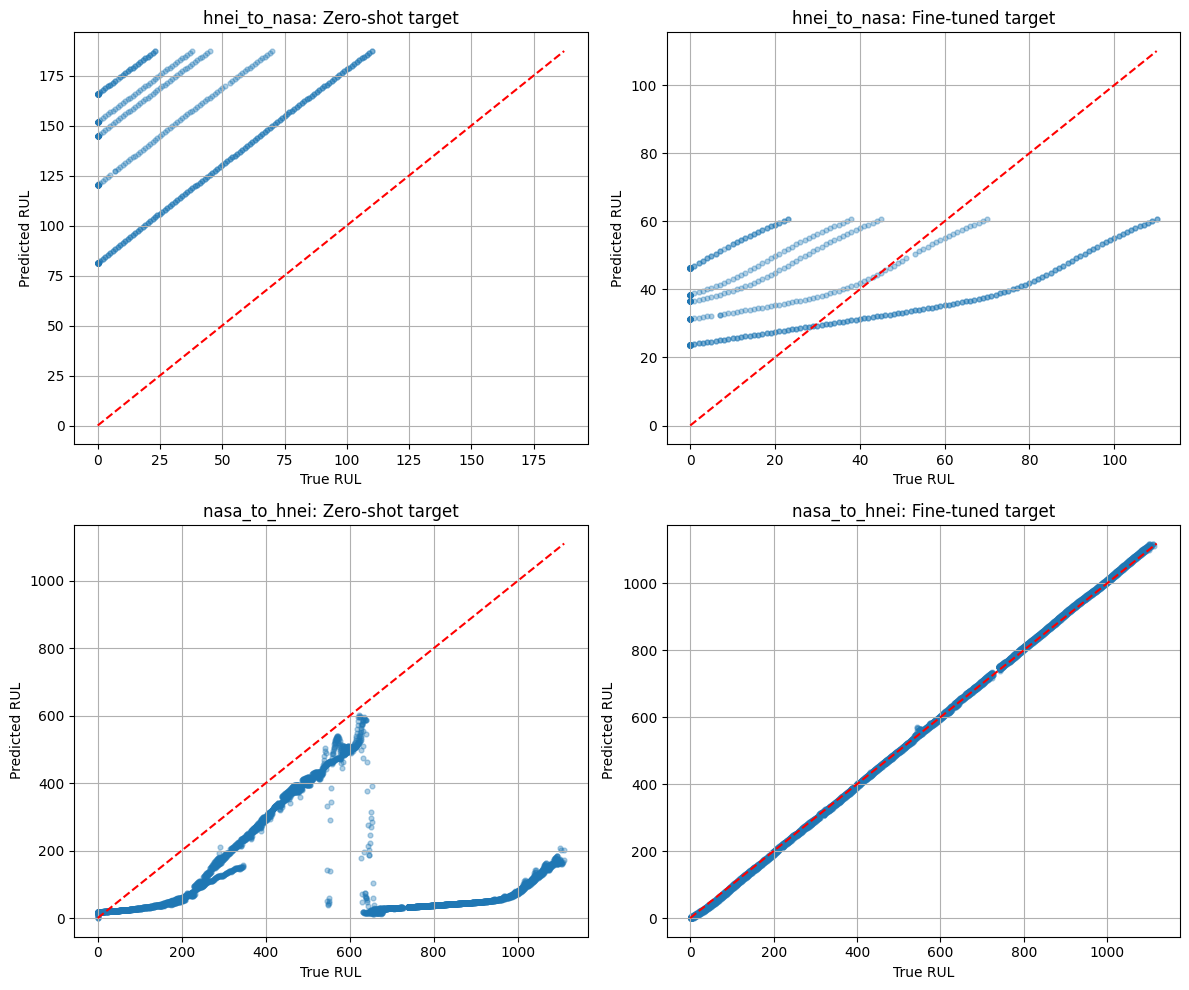

Saved plot to tft_vae_transfer_predictions.png


In [12]:
def plot_transfer_predictions(experiments: list[dict[str, object]]) -> None:
    panels = [
        ("Zero-shot target", "zero_shot_metrics"),
        ("Transfer + fine-tune", "transfer_metrics"),
        ("Target-only small data", "target_only_metrics"),
    ]
    fig, axes = plt.subplots(len(experiments), len(panels), figsize=(5 * len(panels), 5 * len(experiments)))
    if len(experiments) == 1:
        axes = np.array([axes])

    for row, exp in enumerate(experiments):
        for col, (title, key) in enumerate(panels):
            metrics = exp[key]
            actuals = metrics["actuals"]
            preds = metrics["preds"]
            ax = axes[row, col]
            ax.scatter(actuals, preds, alpha=0.35, s=12)
            mn = min(actuals.min(), preds.min())
            mx = max(actuals.max(), preds.max())
            ax.plot([mn, mx], [mn, mx], "--", color="red")
            ax.set_xlabel("True RUL")
            ax.set_ylabel("Predicted RUL")
            ax.set_title(f"{exp['direction']}: {title}")
            ax.grid(True)

    plt.tight_layout()
    plt.savefig("tft_vae_transfer_predictions.png", dpi=150)
    plt.show()
    print("Saved plot to tft_vae_transfer_predictions.png")


plot_transfer_predictions(experiments)
